In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
employee_df = pd.read_csv('Employee_imbalanced.csv')
employee_df.head()

,employee_id,first_name,last_name,age,gender,department,salary,expired_pto
0,1,John,Doe,35,Male,Marketing,50000,n
1,2,Jane,Smith,28,Female,Sales,60000,n
2,3,Michael,Johnson,42,Male,Finance,70000,n
3,4,Emily,Williams,31,Female,HR,55000,y
4,5,James,Brown,37,Male,Operations,65000,n


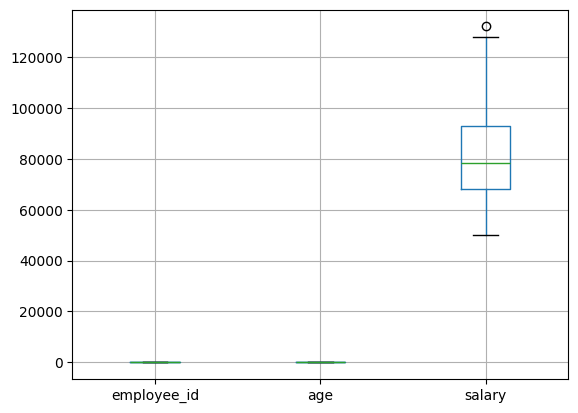

In [14]:
employee_df.boxplot()
plt.show()

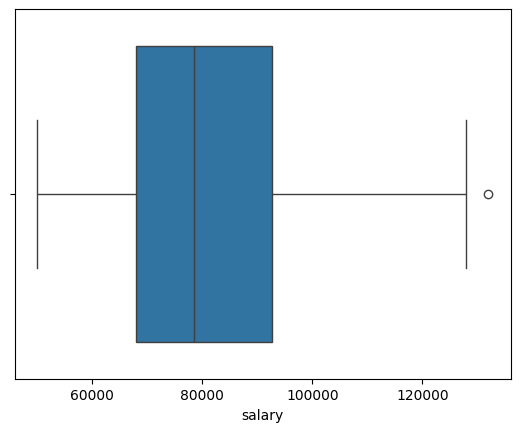

In [15]:
sns.boxplot(employee_df, x='salary')
plt.show()

In [18]:
q1 = employee_df['salary'].quantile(0.25)
q2 = employee_df['salary'].median()
q3 = employee_df['salary'].quantile(0.75)
iqr = q3-q1
iqr

24750.0

In [19]:
min = (q1 - 1.5*iqr)
max = (q3 + 1.5*iqr)
max

129875.0

In [20]:
cond1 = employee_df['salary'] <min
cond2 = employee_df['salary'] >max
outliers = employee_df[cond1 | cond2]
outliers

,employee_id,first_name,last_name,age,gender,department,salary,expired_pto
95,96,Ava,Cook,29,Female,IT,132000,n


In [21]:
employee_df.drop(index=outliers.index,inplace=True)


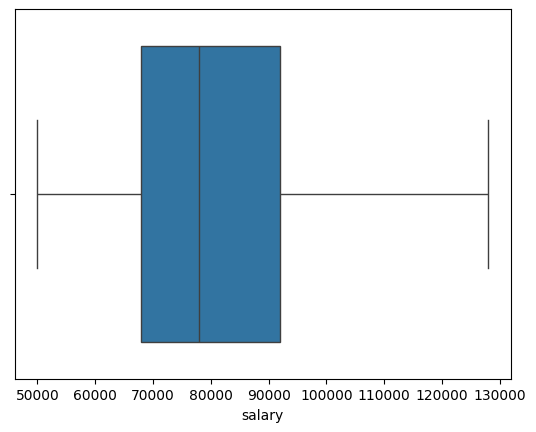

In [22]:
sns.boxplot(employee_df, x='salary')
plt.show()

In [23]:
employee_df = pd.read_csv('Employee_imbalanced.csv')
employee_df.head()

,employee_id,first_name,last_name,age,gender,department,salary,expired_pto
0,1,John,Doe,35,Male,Marketing,50000,n
1,2,Jane,Smith,28,Female,Sales,60000,n
2,3,Michael,Johnson,42,Male,Finance,70000,n
3,4,Emily,Williams,31,Female,HR,55000,y
4,5,James,Brown,37,Male,Operations,65000,n


In [25]:
data = employee_df['salary']
data.head()

0    50000
1    60000
2    70000
3    55000
4    65000
Name: salary, dtype: int64

In [29]:
mean = np.nanmean(data.tolist())
std = np.nanstd(data.tolist())

zscore = (data - mean)/std


threshold = 3
data[(abs(zscore) > threshold)]


Series([], Name: salary, dtype: int64)